In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1 Implement the Environment

In [13]:
def get_reward_and_cost(arm):
    reward_means = [0.8, 0.6, 0.9, 0.4, 0.7]
    reward_stds = [0.1, 0.1, 0.1, 0.1, 0.1]
    costs = [0.2, 0.1, 0.3, 0.05, 0.15]

    reward = np.random.normal(reward_means[arm], reward_stds[arm])
    return reward, costs[arm]

# Step 2: Implement the ε-Greedy Algorithm. Use the net reward (Ri - Ci) to update the Q-values.

In [14]:
def epsilon_greedy_with_costs(num_arms, num_steps, epsilon):
    counts = np.zeros(num_arms)
    Q_values = np.zeros(num_arms)
    cumulative_net_rewards = []
    total_net_reward = 0
    chosen_arms = []
    for t in range(1, num_steps + 1):
        if np.random.rand() < epsilon:
            arm = np.random.randint(num_arms)
        else:
            arm = np.argmax(Q_values)

        chosen_arms.append(arm)
        reward, cost = get_reward_and_cost(arm)
        net_reward = reward - cost
        counts[arm] += 1
        Q_values[arm] += (net_reward - Q_values[arm]) / counts[arm]
        total_net_reward += net_reward
        cumulative_net_rewards.append(total_net_reward)

    return cumulative_net_rewards, chosen_arms

# Step 3 Run the Simulation

In [15]:
# Simulation parameters
num_arms = 5
num_steps = 1000
epsilon = 0.1  # You can change this for experimentation

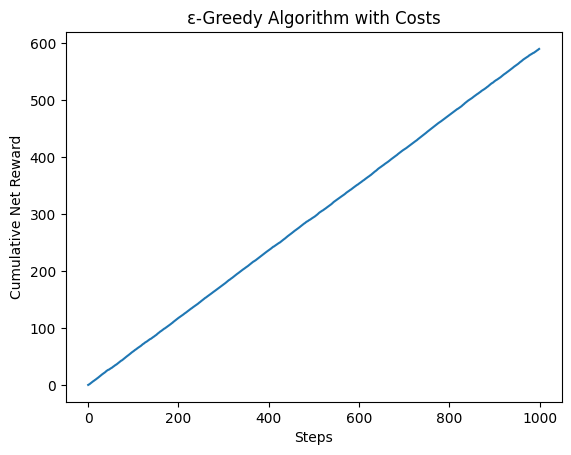

In [16]:
# Run the algorithm
cumulative_net_rewards, _ = epsilon_greedy_with_costs(num_arms, num_steps, epsilon)
# Plot the results
plt.plot(cumulative_net_rewards)
plt.xlabel("Steps")
plt.ylabel("Cumulative Net Reward")
plt.title("ε-Greedy Algorithm with Costs")
plt.show()

# Answer the questions:

## 1a) Explain why we use net rewards (Ri - Ci ) instead of raw rewards (Ri) in this problem. <br>
***We use the net reward instead of just raw reward because in real applications (e.g., delivery drones) every decision carries a cost. This allows the algorithm to balance efficiency and cost, ultimately optimizing overall performance.***

## 1b) How does the ε-greedy algorithm balance exploration and exploitation? <br>

***The ε‑greedy algorithm randomly explores with probability ε and exploits the best-known arm otherwise.***
- High ε: Too much exploration may slow convergence, as the algorithm keeps sampling suboptimal arms.
- Low ε: Too little exploration may cause early convergence on a suboptimal arm if the early samples are not representative.

## 2a) Experimentation: Effect of Different ε (Epsilon) Values

Running the algorithm with ε values such as 0.01, 0.1, and 0.6 shows that a very high ε (0.6) leads to slower learning and lower cumulative net rewards, while a very low ε (0.01) might converge quickly but risk settling for a suboptimal arm. Typically, a moderate ε (like 0.1) offers a good balance.

In [18]:
def run_experiments_epsilon(num_arms, num_steps, epsilons):
    plt.figure(figsize=(10, 6))
    for eps in epsilons:
        cumulative_net_rewards, _ = epsilon_greedy_with_costs(num_arms, num_steps, eps)
        plt.plot(cumulative_net_rewards, label=f"ε = {eps}")
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Net Reward")
    plt.title("Effect of ε on Cumulative Net Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

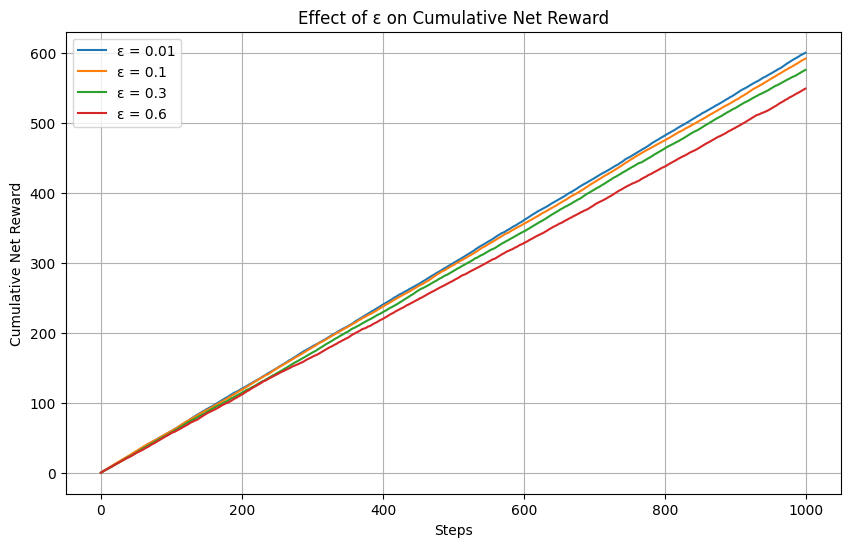

In [19]:
# Experiment with different ε values: 0.01, 0.1, 0.5
run_experiments_epsilon(num_arms, num_steps, epsilons=[0.01, 0.1, 0.3, 0.6])

## 2b) Impact of Higher Costs:

In [36]:
def get_reward_and_cost_modified(arm):
    """
    Simulates the environment by returning the reward and cost for a given arm, with arm number 3 (index 2) modified to have a significantly higher cost.
    """
    reward_means = [0.8, 0.6, 0.9, 0.4, 0.7]
    reward_stds = [0.1, 0.1, 0.1, 0.1, 0.1]
    costs = [0.2, 0.1, 0.8, 0.05, 0.15]

    reward = np.random.normal(reward_means[arm], reward_stds[arm])
    return reward, costs[arm]

In [38]:
def epsilon_greedy_with_modified_costs(num_arms, num_steps, epsilon):
    counts = np.zeros(num_arms)
    Q_values = np.zeros(num_arms)

    cumulative_net_rewards = []
    total_net_reward = 0

    for t in range(1, num_steps + 1):
        # Decide whether to explore or exploit
        if np.random.rand() < epsilon:
            arm = np.random.randint(num_arms)
        else:
            arm = np.argmax(Q_values)

        reward, cost = get_reward_and_cost_modified(arm)
        net_reward = reward - cost

        # Update count and Q-value using incremental update rule
        counts[arm] += 1
        Q_values[arm] += (net_reward - Q_values[arm]) / counts[arm]

        total_net_reward += net_reward
        cumulative_net_rewards.append(total_net_reward)

    return cumulative_net_rewards

***When one arm becomes significantly more expensive (e.g., modifying its cost from 0.3 to 0.9), its net reward drops, and the algorithm learns to avoid it. This results in a re-allocation of choices towards the arms with higher net returns.***

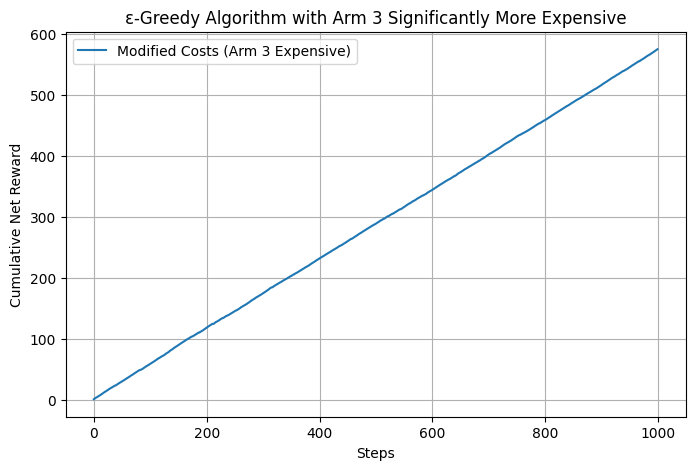

In [39]:
# Run the simulation with modified costs
cumulative_net_rewards_modified = epsilon_greedy_with_modified_costs(
    num_arms, num_steps, epsilon
)
plt.figure(figsize=(8, 5))
plt.plot(cumulative_net_rewards_modified, label="Modified Costs (Arm 3 Expensive)")
plt.xlabel("Steps")
plt.ylabel("Cumulative Net Reward")
plt.title("ε‑Greedy Algorithm with Arm 3 Significantly More Expensive")
plt.legend()
plt.grid(True)
plt.show()

## 3a) epsilon greedy non stationary

In [20]:
def get_reward_and_cost_nonstationary(arm, step):
    """
    Non-stationary environment where costs drift every 100 steps.
    """
    base_reward_means = [0.8, 0.6, 0.9, 0.4, 0.7]
    reward_stds = [0.1, 0.1, 0.1, 0.1, 0.1]
    base_costs = [0.2, 0.1, 0.3, 0.05, 0.15]
    # Every 100 steps, add a random drift between -0.1 and 0.1 to each cost
    drift = (step // 100) * np.random.uniform(-0.1, 0.1, size=len(base_costs))
    current_costs = np.array(base_costs) + drift
    current_costs = np.maximum(current_costs, 0)  # Ensure non-negative costs
    reward = np.random.normal(base_reward_means[arm], reward_stds[arm])
    return reward, current_costs[arm]

In [27]:
def epsilon_greedy_nonstationary(num_arms, num_steps, epsilon):
    counts = np.zeros(num_arms)
    Q_values = np.zeros(num_arms)

    cumulative_net_rewards = []
    total_net_reward = 0

    for t in range(1, num_steps + 1):
        if np.random.rand() < epsilon:
            arm = np.random.randint(num_arms)
        else:
            arm = np.argmax(Q_values)

        reward, cost = get_reward_and_cost_nonstationary(arm, t)
        net_reward = reward - cost

        counts[arm] += 1
        Q_values[arm] += (net_reward - Q_values[arm]) / counts[arm]

        total_net_reward += net_reward
        cumulative_net_rewards.append(total_net_reward)

    return cumulative_net_rewards

### 3b) implement ucb and compare with epsilon greedy

In [48]:
def ucb_with_costs(num_arms, num_steps, c=1.0):
    """
    UCB algorithm with costs.
    """
    counts = np.zeros(num_arms)
    Q_values = np.zeros(num_arms)
    cumulative_net_rewards = []
    total_net_reward = 0
    for arm in range(num_arms):
        reward, cost = get_reward_and_cost_nonstationary(arm, 0)
        net_reward = reward - cost
        Q_values[arm] = net_reward
        counts[arm] = 1
        total_net_reward += net_reward
        cumulative_net_rewards.append(total_net_reward)

    for t in range(num_arms + 1, num_steps + 1):
        ucb_values = Q_values + c * np.sqrt(np.log(t) / counts)
        arm = np.argmax(ucb_values)
        reward, cost = get_reward_and_cost_nonstationary(arm, t)
        net_reward = reward - cost
        counts[arm] += 1
        Q_values[arm] += (net_reward - Q_values[arm]) / counts[arm]
        total_net_reward += net_reward
        cumulative_net_rewards.append(total_net_reward)

    return cumulative_net_rewards

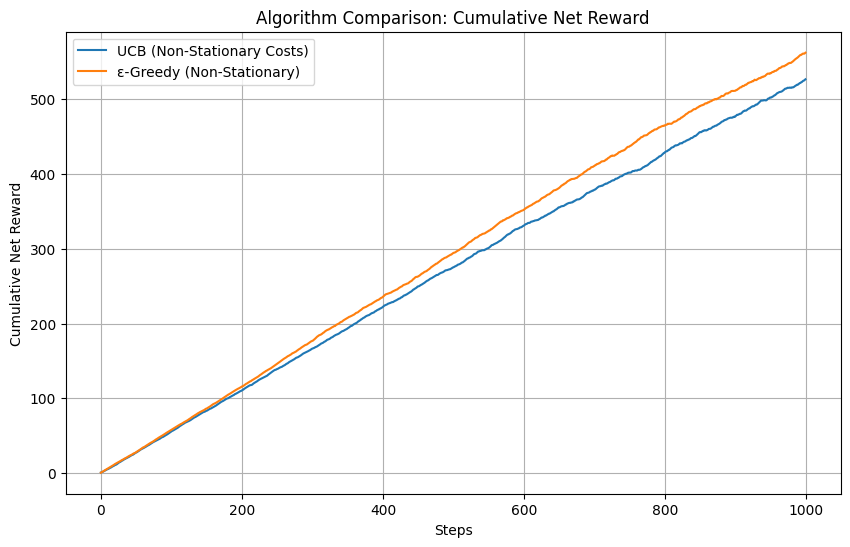

In [50]:
# Run simulation under non-stationary costs
cumulative_net_rewards_nonstat = epsilon_greedy_nonstationary(
    num_arms, num_steps, epsilon=0.1
)
cumulative_net_rewards_ucb = ucb_with_costs(num_arms, num_steps, c=1.0)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_net_rewards_ucb, label="UCB (Non-Stationary Costs)")
plt.plot(cumulative_net_rewards_nonstat, label="ε-Greedy (Non-Stationary)")
plt.xlabel("Steps")
plt.ylabel("Cumulative Net Reward")
plt.title("Algorithm Comparison: Cumulative Net Reward")
plt.legend()
plt.grid(True)
plt.show()

## Which Algorithm Performs Better?
- hard to conclude on a small sample as 1000 steps
- in our case (Non-Stationary) UCB consistently outperforms ε-Greedy over 1000 steps.

## 3C) Dynamic Rewards

In [40]:
def get_reward_and_cost_dynamic(
    arm, step, base_means, sigma, costs, period=200, drift_amplitude=0.2
):
    """
    Simulate an environment where mean rewards (mu_i) shift periodically.
    """
    # Periodic drift using sine function (alternative: random drift)
    phase_shift = (2 * np.pi * step) / period
    dynamic_means = [
        base_mu + drift_amplitude * np.sin(phase_shift + i)
        for i, base_mu in enumerate(base_means)
    ]

    reward = np.random.normal(dynamic_means[arm], sigma)
    return reward, costs[arm]

In [41]:
def epsilon_greedy_dynamic_rewards(num_arms, num_steps, epsilon, period=200):
    """
    Run ε-greedy in a non-stationary environment where means shift periodically.
    """
    # Static parameters
    base_means = [0.8, 0.6, 0.9, 0.4, 0.7]
    sigma = 0.1
    costs = [0.2, 0.1, 0.3, 0.05, 0.15]

    Q_values = np.zeros(num_arms)
    counts = np.zeros(num_arms)

    cumulative_net_rewards = []
    total_net_reward = 0
    arm_selections = []

    for step in range(1, num_steps + 1):
        # Select arm
        if np.random.rand() < epsilon:
            arm = np.random.randint(num_arms)
        else:
            arm = np.argmax(Q_values)

        reward, cost = get_reward_and_cost_dynamic(
            arm, step, base_means, sigma, costs, period
        )
        net_reward = reward - cost

        # Update Q-values
        counts[arm] += 1
        Q_values[arm] += (net_reward - Q_values[arm]) / counts[arm]

        total_net_reward += net_reward
        cumulative_net_rewards.append(total_net_reward)
        arm_selections.append(arm)

    return cumulative_net_rewards, arm_selections

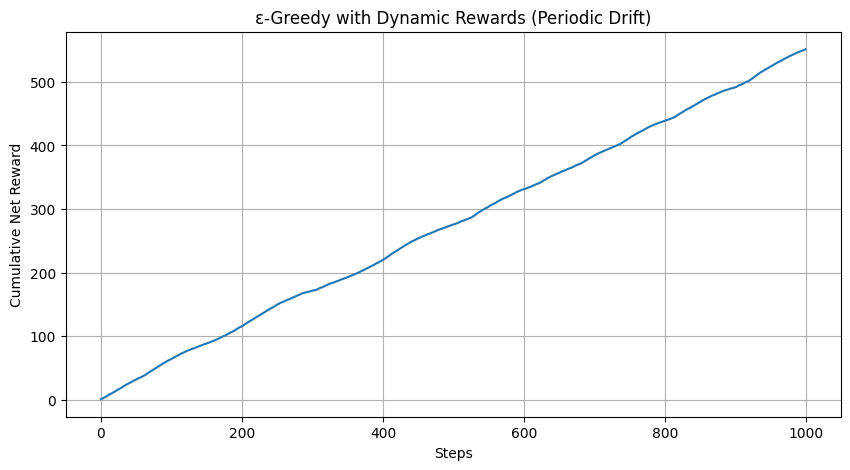

In [42]:
period = 200  # reward drift every 200 steps
# Run ε-greedy in dynamic rewards
cumulative_rewards_dyn, selected_arms_dyn = epsilon_greedy_dynamic_rewards(
    num_arms, num_steps, epsilon, period
)
plt.figure(figsize=(10, 5))
plt.plot(cumulative_rewards_dyn)
plt.xlabel("Steps")
plt.ylabel("Cumulative Net Reward")
plt.title("ε-Greedy with Dynamic Rewards (Periodic Drift)")
plt.grid(True)
plt.show()

- Cumulative reward grows, but with fluctuating slopes, showing adaptation to periodic reward changes.
- After each drift, there's a short lag—the algorithm takes time to re-learn the new optimal arm.
- ε-greedy relies on exploration to adapt, but without a decay mechanism, it responds slowly.

***Overall, it adapts, but not instantly—performance dips after changes, then recovers.***

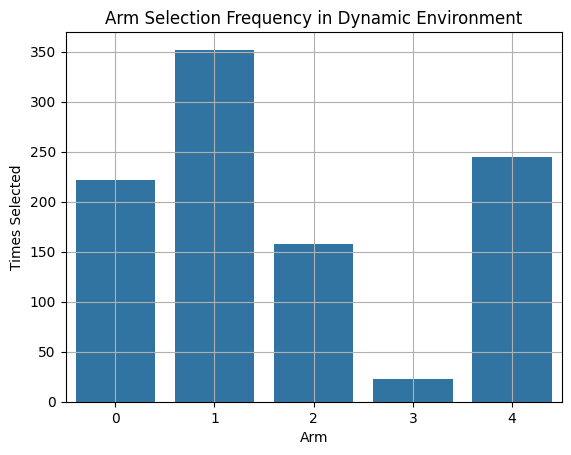

In [43]:
import seaborn as sns
import pandas as pd

arm_counts = pd.Series(selected_arms_dyn).value_counts().sort_index()
sns.barplot(x=arm_counts.index, y=arm_counts.values)
plt.xlabel("Arm")
plt.ylabel("Times Selected")
plt.title("Arm Selection Frequency in Dynamic Environment")
plt.grid(True)
plt.show()

# 4. Analysis:
## 4a) Calculate the regret for the ε-greedy algorithm.

In [30]:
def calculate_regret(cumulative_rewards):
    """
    Calculate the regret over time.
    """
    reward_means = [0.8, 0.6, 0.9, 0.4, 0.7]
    costs = [0.2, 0.1, 0.3, 0.05, 0.15]
    expected_net_rewards = [m - c for m, c in zip(reward_means, costs)]
    optimal_arm = np.argmax(expected_net_rewards)
    optimal_net_reward = expected_net_rewards[optimal_arm]
    regrets = [
        optimal_net_reward * (i + 1) - r for i, r in enumerate(cumulative_rewards)
    ]
    return regrets

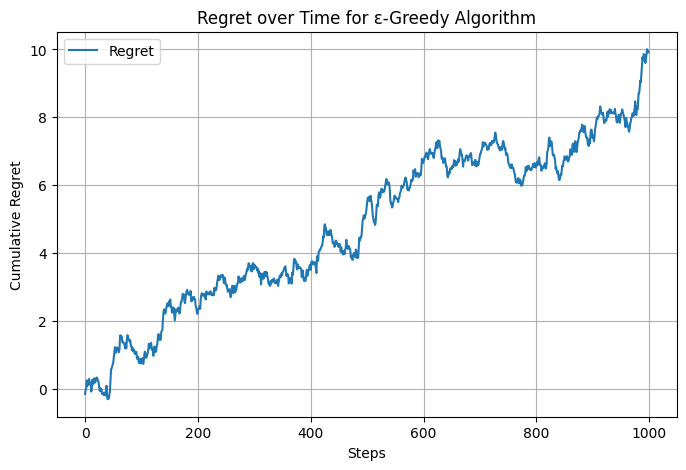

In [32]:
# Using the ε-greedy cumulative rewards (from previous simulation)
regrets = calculate_regret(cumulative_net_rewards)

plt.figure(figsize=(8, 5))
plt.plot(regrets, label="Regret")
plt.xlabel("Steps")
plt.ylabel("Cumulative Regret")
plt.title("Regret over Time for ε-Greedy Algorithm")
plt.legend()
plt.grid(True)
plt.show()

## 4b) how regret grows over time

For a well‑designed algorithm, regret grows sublinearly over time, meaning that while initially there may be a substantial difference, the average regret per step decreases as the algorithm learns. A linear growth would indicate that the algorithm is not learning effectively.